# Clasificación y estimación facial mediante Python para la seguridad en entornos   

## Descripción del dataset FGNET

In [1]:
#Librerias

import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path 
from deepface import DeepFace
from tqdm import tqdm
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')


/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Cargar el dataset
dataset = Path("/Users/camilazuniga/Desktop/DATA SCIENCE/AED/FGNET/images")
ruta_csv = "/Users/camilazuniga/Documents/GitHub/EDA-FGNET/FGNET_dataset.csv"


if dataset.exists():
    print("El dataset se ha cargado correctamente.")
else:
    print("El dataset no se encuentra en la ruta especificada.")

El dataset se ha cargado correctamente.


Se encontraron 1002 imágenes en el dataset.


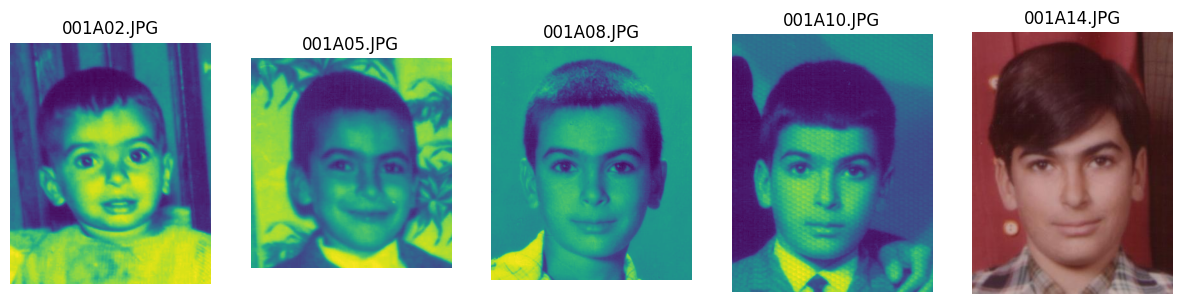

Las cinco primeras imágenes del dataset:
  - 001A02.JPG
  - 001A05.JPG
  - 001A08.JPG
  - 001A10.JPG
  - 001A14.JPG


In [3]:
# Listar imágenes en el dataset
extensiones = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
image = [f for f in dataset.iterdir() if f.suffix.lower() in extensiones]
image = sorted(image, key=lambda x: x.name)
print(f"Se encontraron {len(image)} imágenes en el dataset.")

# Mostrar las primeras 5 imágenes
num_images_to_show = 5
plt.figure(figsize=(15, 10))
for i, image_file in enumerate(image[:num_images_to_show]):
    img = Image.open(image_file)
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(image_file.name)
    plt.axis('off')
plt.show()

print("Las cinco primeras imágenes del dataset:")
for img in image[:5]:
    print(f"  - {img.name}")

# Función para extraer edad del nombre del archivo
def extraer_edad(fgnet):
    stem = Path(fgnet).stem
    match = re.search(r'[a-zA-Z](\d+)', stem)
    if match:
        return int(match.group(1))
    else:
        return None


In [4]:
# Crear DataFrame con datos estructurados 
data = []

for img in image:
    stats = img.stat()
    edad = extraer_edad(img.name)
    data.append({
        'imagenes': img.name,
        'Tamaño_KB': round(stats.st_size / 1024, 2),
        'Edad': edad,
        'Sexo': None,
        'R': None,
        'G': None,
        'B': None
    })

df = pd.DataFrame(data)
df = df.sort_values('imagenes').reset_index(drop=True)

# Guardar CSV inicial
df.to_csv(ruta_csv, index=False)

print(f"CSV creado con {len(df)} imágenes")
print(f"   Edad detectada: {df['Edad'].notna().sum()}")
print(f"   Edad no detectada: {df['Edad'].isna().sum()}")



CSV creado con 1002 imágenes
   Edad detectada: 1002
   Edad no detectada: 0


In [5]:
# Cargar el dataset desde el CSV
df = pd.read_csv(ruta_csv)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 1002 filas, 7 columnas


In [6]:
# Implementar DeepFace para analizar género
print("Analizando género en cada imagen...")
predicciones = []

for img_name in tqdm(df['imagenes'], desc="Procesando género"):
    img_path = dataset / img_name
    try:
        analisis = DeepFace.analyze(
            str(img_path), 
            actions=['gender'], 
            detector_backend='opencv', 
            enforce_detection=False,
            silent=True
        )
        genero = analisis[0]['dominant_gender']  
        predicciones.append(genero)
    except Exception:
        predicciones.append('No_detectado')

df['Sexo'] = predicciones

# Guardar 
df.to_csv(ruta_csv, index=False)

print(f"\nDistribución estimada de género:")
print(df['Sexo'].value_counts())

Analizando género en cada imagen...


Procesando género: 100%|██████████| 1002/1002 [01:49<00:00,  9.17it/s]


Distribución estimada de género:
Sexo
Man      720
Woman    282
Name: count, dtype: int64


La data no está representada debido a que hay más hombres que mujeres.

Distribución estimada: Sexo
- Man      719
- Woman    283

In [7]:
# Implementar la variable RGB para cada imagen
print("\nAnalizando color RGB en cada imagen...")
rgb_values = [] 
for img_name in tqdm(df['imagenes'], desc="Procesando RGB"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            bgr = cv2.mean(img)[:3]  
            rgb = tuple(reversed(bgr))
            rgb_values.append(rgb)
        else:
            rgb_values.append((0, 0, 0))  
    except Exception:
        rgb_values.append((0, 0, 0))

df['RGB'] = rgb_values
df[['R', 'G', 'B']] = pd.DataFrame(df['RGB'].tolist(), index=df.index)

# Guardar 
df.to_csv(ruta_csv, index=False)

print("Análisis RGB completado")


Analizando color RGB en cada imagen...


Procesando RGB: 100%|██████████| 1002/1002 [00:00<00:00, 1906.32it/s]

Análisis RGB completado


In [8]:

# Calidad de imagenes
print("\nAnalizando calidad de imagen...")
calidad_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando calidad"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            calidad = cv2.Laplacian(img, cv2.CV_64F).var()
            calidad_values.append(calidad)
        else:
            calidad_values.append(0)  
    except Exception:
        calidad_values.append(0)    
    
df['Calidad'] = calidad_values
df.to_csv(ruta_csv, index=False)




Analizando calidad de imagen...


Procesando calidad: 100%|██████████| 1002/1002 [00:01<00:00, 818.20it/s]


In [9]:
# Pixeles en cada imagen
print("\nAnalizando cantidad de pixeles en cada imagen...")
pixeles_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando pixeles"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            pixeles = img.shape[0] * img.shape[1]
            pixeles_values.append(pixeles)
        else:
            pixeles_values.append(0)  
    except Exception:
        pixeles_values.append(0)

df['Pixeles'] = pixeles_values
df.to_csv(ruta_csv, index=False)


Analizando cantidad de pixeles en cada imagen...


Procesando pixeles: 100%|██████████| 1002/1002 [00:00<00:00, 2231.78it/s]


In [10]:
# Implementar variables de brillo
print("\nAnalizando brillo en cada imagen...")
brillo_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando brillo"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brillo = img.mean()
            brillo_values.append(brillo)
        else:
            brillo_values.append(0)  
    except Exception:
        brillo_values.append(0)
df['Brillo'] = brillo_values
df.to_csv(ruta_csv, index=False)
print("Análisis de brillo completado")


Analizando brillo en cada imagen...


Procesando brillo: 100%|██████████| 1002/1002 [00:00<00:00, 2139.05it/s]

Análisis de brillo completado


In [11]:
# Implementar la variable de contraste
print("\nAnalizando contraste en cada imagen...")
contraste_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando contraste"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            contraste = img.std()
            contraste_values.append(contraste)
        else:
            contraste_values.append(0)  
    except Exception:
        contraste_values.append(0)
df['Contraste'] = contraste_values
df.to_csv(ruta_csv, index=False)
print("Análisis de contraste completado")


Analizando contraste en cada imagen...


Procesando contraste: 100%|██████████| 1002/1002 [00:00<00:00, 1675.91it/s]

Análisis de contraste completado


In [12]:
# Implementar la varible de nitidez
print("\nAnalizando nitidez en cada imagen...")
nitidez_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando nitidez"):    
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            nitidez = cv2.Laplacian(img, cv2.CV_64F).var()
            nitidez_values.append(nitidez)
        else:
            nitidez_values.append(0)  
    except Exception:
        nitidez_values.append(0)
df['Nitidez'] = nitidez_values
df.to_csv(ruta_csv, index=False)
print("Análisis de nitidez completado")


Analizando nitidez en cada imagen...


Procesando nitidez: 100%|██████████| 1002/1002 [00:00<00:00, 1480.13it/s]

Análisis de nitidez completado


In [16]:
# Mostrar el dataset 
print("=" * 60)
print("DATASET FGNET") #con datos estructurados"
print("=" * 60)

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

print("\n Primeras 10 filas del dataset:")
display(df.head(10))

print("\n Información del dataset:")
df.info()

print("\n Estadísticas descriptivas:")
display(df.describe())


DATASET FGNET

Dimensiones: 1002 filas × 14 columnas

Columnas: ['imagenes', 'Tamaño_KB', 'Edad', 'Sexo', 'R', 'G', 'B', 'RGB', 'Calidad', 'Pixeles', 'Brillo', 'Contraste', 'Nitidez', 'Categoria_Edad']

 Primeras 10 filas del dataset:


,imagenes,Tamaño_KB,Edad,Sexo,R,G,B,RGB,Calidad,Pixeles,Brillo,Contraste,Nitidez,Categoria_Edad
0,001A02.JPG,9.55,2,Woman,102.936847,102.936847,102.936847,"(102.93684728745984, 102.93684728745984, 102.9...",14.565980,123906,102.936847,52.954320,14.565980,Niño
1,001A05.JPG,12.55,5,Man,133.466402,133.466402,133.466402,"(133.46640236073256, 133.46640236073256, 133.4...",10.937652,177572,133.466402,47.626867,10.937652,Niño
2,001A08.JPG,12.54,8,Man,138.786665,138.786665,138.786665,"(138.78666468886746, 138.78666468886746, 138.7...",14.906851,202245,138.786665,29.309509,14.906851,Niño
3,001A10.JPG,14.12,10,Man,111.491709,111.491709,111.491709,"(111.49170883317224, 111.49170883317224, 111.4...",25.312660,158301,111.491709,48.384509,25.312660,Niño
4,001A14.JPG,10.57,14,Man,114.376567,64.713975,63.699782,"(114.3765671746721, 64.71397548763055, 63.6997...",14.457277,128017,79.450089,40.450270,12.233492,Adolescente
5,001A16.JPG,58.06,16,Man,126.296435,126.296435,126.296435,"(126.29643549263342, 126.29643549263342, 126.2...",106.820466,493308,126.296435,54.556714,106.820466,Adolescente
6,001A18.JPG,16.39,18,Man,150.180489,76.964194,61.682092,"(150.18048877097957, 76.96419425560529, 61.682...",12.698099,217116,97.172659,38.755604,10.074829,Adulto
7,001A19.JPG,18.52,19,Man,156.591782,76.827312,58.073008,"(156.59178216974675, 76.82731220054757, 58.073...",53.271038,187008,98.544036,39.245843,50.946136,Adulto
8,001A22.JPG,34.81,22,Man,159.241437,128.307665,113.630621,"(159.24143701982277, 128.3076646260037, 113.63...",25.655989,230644,135.912935,55.874923,23.676302,Adulto
9,001A28.JPG,14.51,28,Man,94.887594,87.523791,87.852513,"(94.88759449562959, 87.523791243405, 87.852512...",10.911139,203184,89.786479,34.446613,9.051681,Adulto



 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   imagenes        1002 non-null   object  
 1   Tamaño_KB       1002 non-null   float64 
 2   Edad            1002 non-null   int64   
 3   Sexo            1002 non-null   object  
 4   R               1002 non-null   float64 
 5   G               1002 non-null   float64 
 6   B               1002 non-null   float64 
 7   RGB             1002 non-null   object  
 8   Calidad         1002 non-null   float64 
 9   Pixeles         1002 non-null   int64   
 10  Brillo          1002 non-null   float64 
 11  Contraste       1002 non-null   float64 
 12  Nitidez         1002 non-null   float64 
 13  Categoria_Edad  1002 non-null   category
dtypes: category(1), float64(8), int64(2), object(3)
memory usage: 103.1+ KB

 Estadísticas descriptivas:


,Tamaño_KB,Edad,R,G,B,Calidad,Pixeles,Brillo,Contraste,Nitidez
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,44.114681,15.840319,108.362976,87.325224,80.161416,34.592948,202213.066866,92.802639,49.787973,31.685342
std,12.187962,12.867280,24.267356,21.779225,24.085586,43.397043,28346.161994,21.055310,11.574078,43.381593
min,7.850000,0.000000,47.103134,33.284418,23.008612,3.049299,110827.000000,37.678779,18.205912,3.049299
25%,39.195000,6.000000,90.828113,71.777986,63.035480,14.219920,194889.000000,78.100225,41.611730,11.251506
50%,45.260000,13.000000,105.448688,85.086661,77.339972,21.826176,203102.500000,90.319603,49.309756,18.788824
75%,51.062500,22.000000,123.351280,100.428520,93.868196,38.433359,208566.000000,105.633029,56.895394,34.870997
max,97.910000,69.000000,212.378051,159.890851,163.178075,685.121769,493308.000000,159.890851,89.819889,687.280925


## Análisis Exploratorio de Datos I

### i. Análisis exploratorio Univariado 

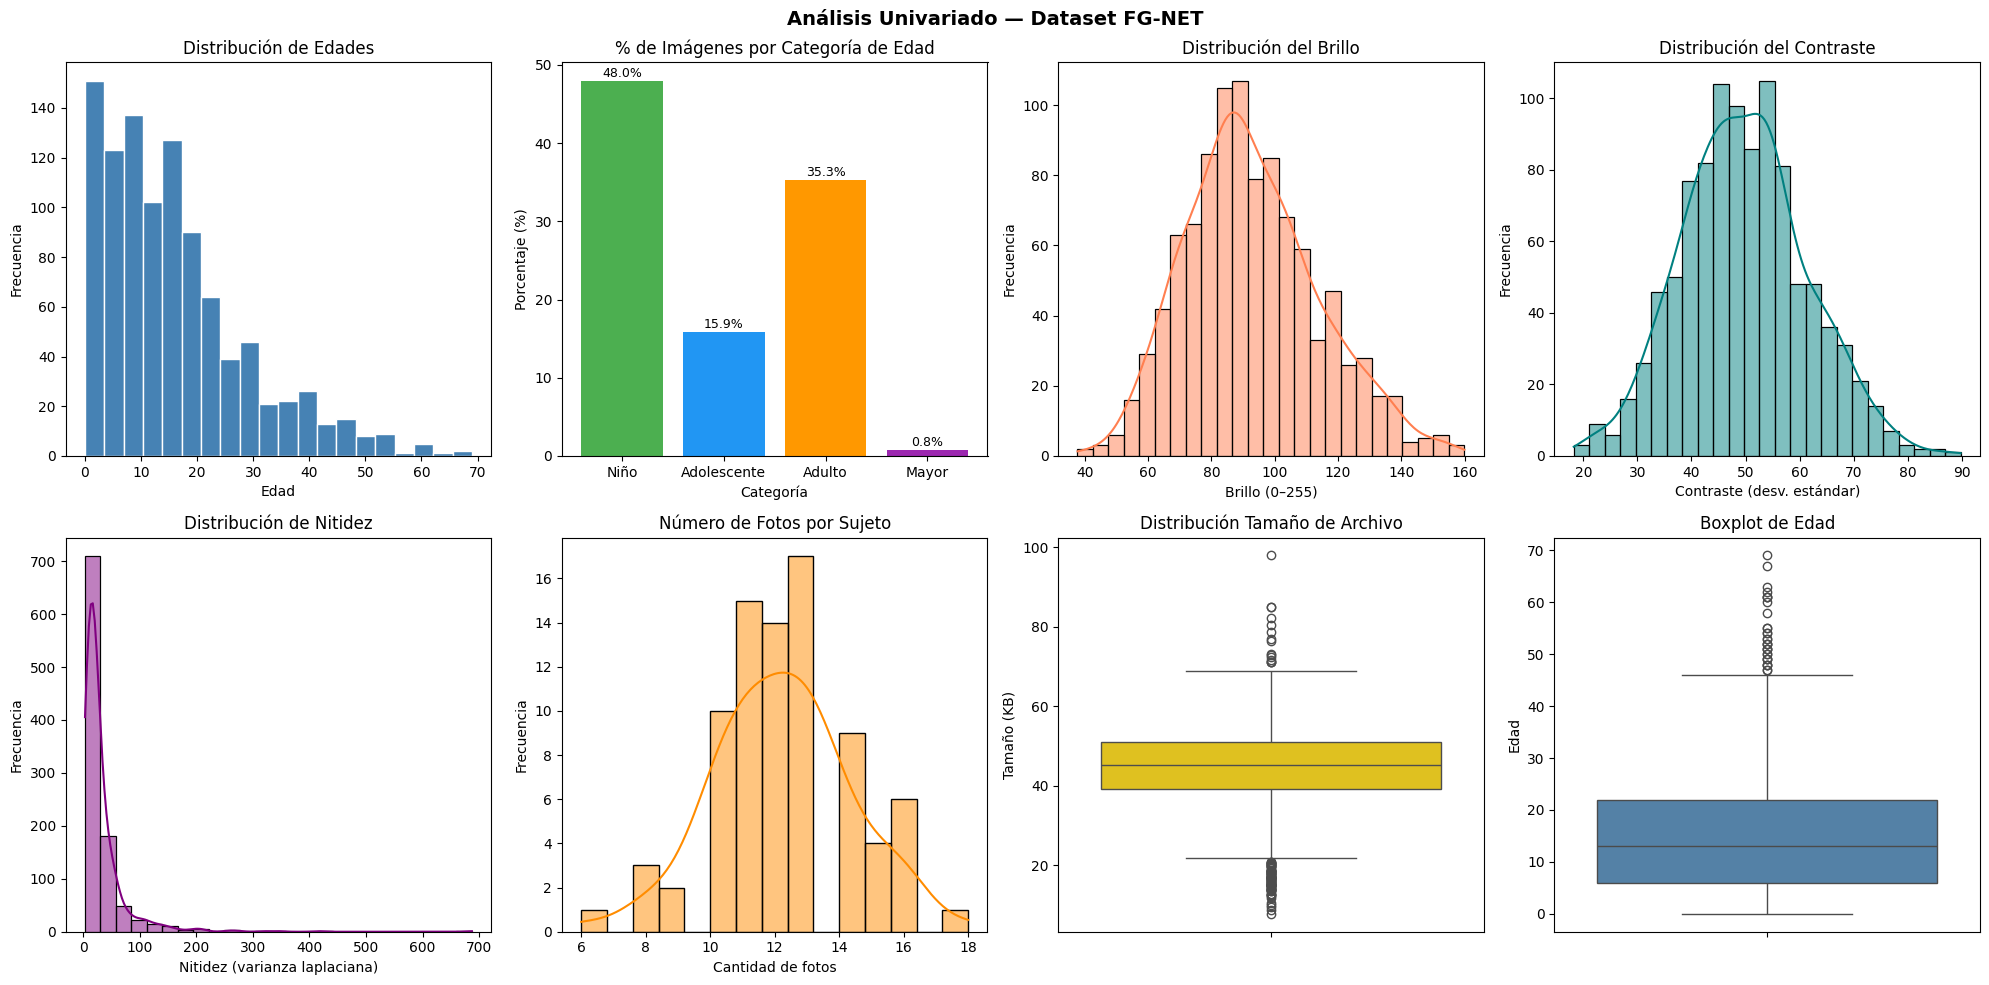

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Análisis Univariado — Dataset FG-NET', fontsize=14, fontweight='bold')

axes[0,0].hist(df['Edad'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Edades')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')

cat_bins = [0, 12, 17, 59, float('inf')]
cat_labels = ['Niño', 'Adolescente', 'Adulto', 'Mayor']
df['Categoria_Edad'] = pd.cut(df['Edad'], bins=cat_bins, labels=cat_labels, right=True, include_lowest=True)

cat_pct = df['Categoria_Edad'].value_counts(normalize=True) * 100
orden = ['Niño','Adolescente','Adulto','Mayor']
cat_pct = cat_pct.reindex([c for c in orden if c in cat_pct.index])

axes[0,1].bar(cat_pct.index, cat_pct.values, color=['#4CAF50','#2196F3','#FF9800','#9C27B0'])
axes[0,1].set_title('% de Imágenes por Categoría de Edad')
axes[0,1].set_xlabel('Categoría')
axes[0,1].set_ylabel('Porcentaje (%)')

for i, v in enumerate(cat_pct.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

sns.histplot(df['Brillo'].dropna(), bins=25, kde=True, ax=axes[0,2], color='coral')
axes[0,2].set_title('Distribución del Brillo')
axes[0,2].set_xlabel('Brillo (0–255)')
axes[0,2].set_ylabel('Frecuencia')

sns.histplot(df['Contraste'].dropna(), bins=25, kde=True, ax=axes[0,3], color='teal')
axes[0,3].set_title('Distribución del Contraste')
axes[0,3].set_xlabel('Contraste (desv. estándar)')
axes[0,3].set_ylabel('Frecuencia')

sns.histplot(df['Nitidez'].dropna(), bins=25, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribución de Nitidez')
axes[1,0].set_xlabel('Nitidez (varianza laplaciana)')
axes[1,0].set_ylabel('Frecuencia')

fotos_por_sujeto = df['imagenes'].str[:3].value_counts()

sns.histplot(fotos_por_sujeto, bins=15, ax=axes[1,1], color='darkorange', kde=True)
axes[1,1].set_title('Número de Fotos por Sujeto')
axes[1,1].set_xlabel('Cantidad de fotos')
axes[1,1].set_ylabel('Frecuencia')

sns.boxplot(y=df['Tamaño_KB'], ax=axes[1,2], color='gold')
axes[1,2].set_title('Distribución Tamaño de Archivo')
axes[1,2].set_ylabel('Tamaño (KB)')

sns.boxplot(y=df['Edad'], ax=axes[1,3], color='steelblue')
axes[1,3].set_title('Boxplot de Edad')
axes[1,3].set_ylabel('Edad')

plt.tight_layout()
plt.show()



### ii. Análisis exploratorio Bivariado. 

### iii. Análisis exploratorio Multivariado